<a href="https://colab.research.google.com/github/ShaktiSampadSwain/Sentiment-Analysis/blob/main/Sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import os

In [ ]:
!pip install tensorflow tensorflow-gpu opencv-python matplotlib

In [ ]:
!pip install opencv-python

In [ ]:
# Avoid OOM errors by setting GPU Memory Consumption Growth

gpus = tf.config.experimental.list_physical_devices('GPU')

for gpu in gpus:

  tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
import cv2
import imghdr

C:\Users\SHAKTI\AppData\Local\Temp\ipykernel_10160\4232469594.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
data_dir = 'MLproject_1/Data'
image_exts =  ['jpeg', 'jpg', 'png', 'bmp']

In [ ]:
#os.listdir(os.path.join(data_dir, 'happy'))

In [ ]:
for image_class in os.listdir(data_dir):
  for image in os.listdir(os.path.join(data_dir, image_class)):
    image_path = os.path.join(data_dir, image_class, image)
    try:
      img = cv2.imread(image_path)
      tip = imghdr.what(image_path)
      if tip not in image_exts:
        os.remove(image_path)

    except Exception as e :
      print('issue with image{}'. format(image_path))


In [ ]:
!pip install matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
data = tf.keras.utils.image_dataset_from_directory('MLproject_1/Data')

Found 1271 files belonging to 2 classes.


In [ ]:
data_iterator = data.as_numpy_iterator()

In [ ]:
batch = data_iterator.next()

In [ ]:
# images represented as numpy array
batch[0].shape

(32, 256, 256, 3)

In [ ]:
# lables for each batch
batch[1]

array([1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0])

In [ ]:
batch[0].max()

255.0

In [ ]:
data = data.map( lambda x,y : (x/255 , y))


In [ ]:
sacled_iterator = data.as_numpy_iterator()

In [ ]:
batch = sacled_iterator.next()

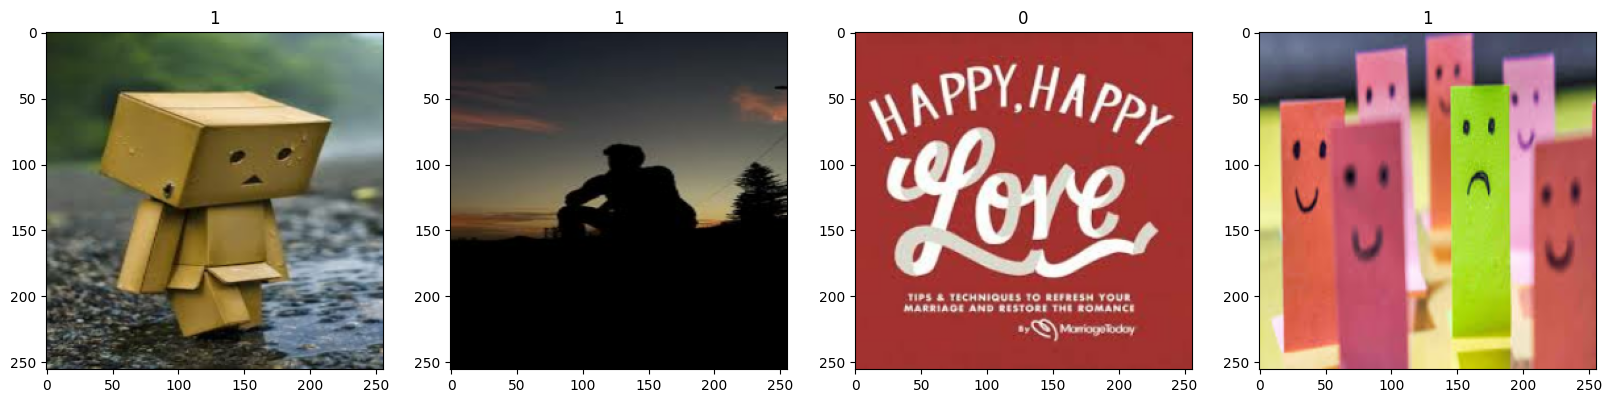

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])


## split data

In [ ]:
len(data)

40

In [ ]:
train_size = int(len(data)*.8)
val_size = int(len(data)*.15)
test_size = int(len(data)*.05)
val_size

6

In [ ]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

# deep learning network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

model = Sequential()
model.add(Conv2D(16,(3,3),1, activation = 'relu', input_shape =(256, 256, 3)))
model.add(MaxPooling2D())


model.add(Conv2D(16,(3,3),1, activation = 'relu'))
model.add(MaxPooling2D())

model.add(Conv2D(8,(3,3),1, activation = 'relu', input_shape =(256, 256, 3)))
model.add(MaxPooling2D())
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(256, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [ ]:
model.compile('adam', loss= tf.keras.losses.binary_crossentropy, metrics='accuracy') # or put loss= tf.keras.losses.BinaryCrossentropy()

In [ ]:
model.summary()

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_44 (Conv2D)          (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d_44 (MaxPooli  (None, 127, 127, 16)      0         
 ng2D)                                                           
                                                                 
 conv2d_45 (Conv2D)          (None, 125, 125, 16)      2320      
                                                                 
 max_pooling2d_45 (MaxPooli  (None, 62, 62, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_46 (Conv2D)          (None, 60, 60, 8)         1160      
                                                                 
 max_pooling2d_46 (MaxPooli  (None, 30, 30, 8)       

In [ ]:
logdir = '/content/logs'


In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = logdir)

In [ ]:
hist = model.fit(train, epochs = 20,validation_data = val, callbacks= [tensorboard_callback])

Epoch 1/20
32/32 [==============================] - 11s 331ms/step - loss: 0.1351 - accuracy: 0.9531 - val_loss: 0.2266 - val_accuracy: 0.9271
Epoch 2/20
32/32 [==============================] - 11s 328ms/step - loss: 0.1178 - accuracy: 0.9590 - val_loss: 0.2486 - val_accuracy: 0.9271
Epoch 3/20
32/32 [==============================] - 11s 325ms/step - loss: 0.0607 - accuracy: 0.9844 - val_loss: 0.1330 - val_accuracy: 0.9635
Epoch 4/20
32/32 [==============================] - 11s 327ms/step - loss: 0.0667 - accuracy: 0.9775 - val_loss: 0.1655 - val_accuracy: 0.9635
Epoch 5/20
32/32 [==============================] - 11s 328ms/step - loss: 0.1049 - accuracy: 0.9697 - val_loss: 0.3086 - val_accuracy: 0.9062
Epoch 6/20
32/32 [==============================] - 11s 326ms/step - loss: 0.0723 - accuracy: 0.9756 - val_loss: 0.1739 - val_accuracy: 0.9583
Epoch 7/20
32/32 [==============================] - 11s 327ms/step - loss: 0.0583 - accuracy: 0.9795 - val_loss: 0.2689 - val_accuracy: 0.9219

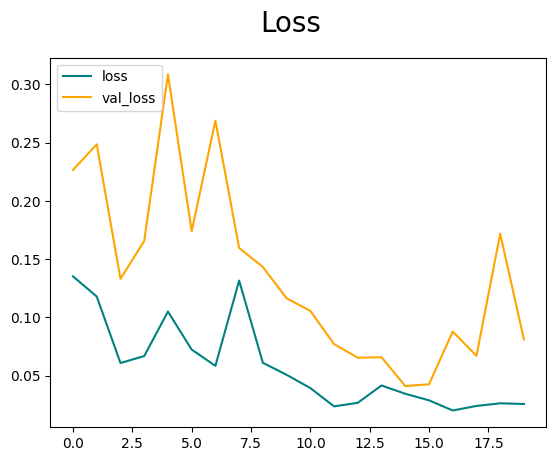

In [ ]:
fig = plt.figure()

plt.plot(hist.history['loss'], color='teal', label='loss')

plt.plot(hist.history['val_loss'], color='orange', label='val_loss')

fig.suptitle('Loss', fontsize=20)

plt.legend(loc="upper left")

plt.show()

## Evaluating and Testing

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [ ]:
for batch in test.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  pre.update_state(y, yhat)
  re.update_state(y, yhat)
  acc.update_state(y, yhat)

1/1 [==============================] - 0s 64ms/step


In [ ]:
print(f'Precision:{(pre.result().numpy())}, Recall: {(re.result().numpy())}, Accuracy: {(acc.result().numpy())}')

Precision:0.9642857313156128, Recall: 1.0, Accuracy: 0.9818181991577148


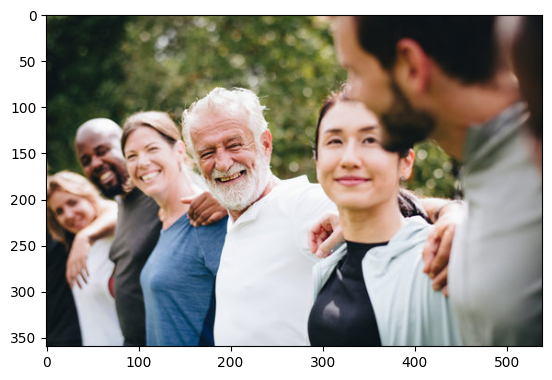

In [ ]:
img = cv2.imread('MLproject_1/Data/happy/360_F_237330799_fynB7PDF8qXuq2qYTEKOa6E0Lt8Vbzv6.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

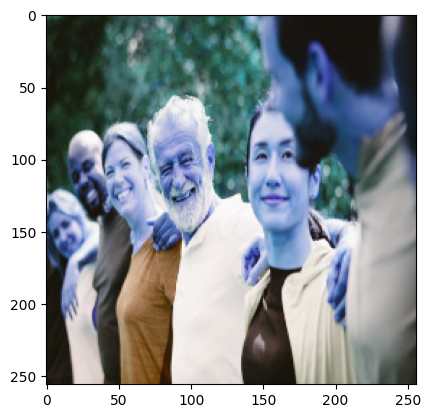

In [ ]:
resize = tf.image.resize(img, (256,256))

plt.imshow(resize.numpy().astype(int))

plt.show()

In [ ]:
yhat = model.predict(np.expand_dims(resize/255,0))

1/1 [==============================] - 0s 17ms/step


In [ ]:
yhat

array([[0.2784668]], dtype=float32)

In [ ]:
if yhat > 0.5 :
  print('person is sad')
else :
  print('person is happy')

person is happy


In [ ]:
from tensorflow.keras.models import load_model
model.save(os.path.join('MLproject_1', 'sentiment_analysis_2.h5'))

In [ ]:
# model.save(os.path.join('/content/drive/MyDrive/Colab Notebooks/Models', 'sentiment_analysis_1.keras'))

In [ ]:
#import tensorflow as tf


In [ ]:
#new_model = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/Models/sentiment_analysis_1.keras')

# Show the model architecture
#new_model.summary()

In [ ]:
#import pickle

In [ ]:
#pickle.dump(new_model,open('img_sentiment.pkl','wb'))

In [ ]:
#weights = new_model.get_weights(); new_model.set_weights(weights)

In [ ]:
#import os

In [ ]:
#new_model.save(os.path.join('/content/drive/MyDrive/Colab Notebooks/Models', 'img_senti.h5'))